# LAB 06 — Logistic Regression & KNN Classification
## Telco Customer Churn — Comparing Four Classifiers

## Student Information
**Name:** Faryal Gul

**Student ID:**  023-24-0014

**Section:** B

**GitHub:**

**Kaggle:**

**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Logistic Regression and KNN theory from your ML course. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [14]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Verification

Re-establish your cleaned dataset and recall what Lab 3/4 already found.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [15]:
# Task 1 — load and verify the cleaned dataset
df=pd.read_csv("clean_churn.csv")
print(df.shape)
print(df.info())

(7010, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str    


**Answer 2 (Lab 3/4 recap):**
In Lab 3, the Decision Tree achieved 79.31% accuracy, 63.10% precision, 52.56% recall, and 57.35% F1-score on the test set. In Lab 4, the Random Forest achieved 78.95% accuracy, 63.66% precision, 47.70% recall, and 54.54% F1-score with default settings, while the tuned Random Forest achieved 80.09% accuracy, 66.19% precision, 50.67% recall, and 57.40% F1-score. These results will be used as benchmarks for comparing Logistic Regression and KNN in this lab.


---

## 2. Feature Scaling & Preparation

Decision Trees/Random Forests never needed scaling. Logistic Regression and especially KNN do.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `from sklearn.preprocessing import StandardScaler`, `scaler.fit_transform(X_train)`, `scaler.transform(X_test)`

**Tasks**
3. Prepare `X` and `y` exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [16]:
# Task 3 — define X and y (same as Lab 3/4)
y=df["Churn"].map({"No": 0, "Yes": 1})
x=df.drop(columns=["Churn"])
x=pd.get_dummies(x,drop_first=True)
x=x.astype("int32")
print(x.dtypes)
print(y.dtypes)

SeniorCitizen                            int32
tenure                                   int32
MonthlyCharges                           int32
TotalCharges                             int32
gender_Male                              int32
Partner_Yes                              int32
Dependents_Yes                           int32
PhoneService_Yes                         int32
MultipleLines_No phone service           int32
MultipleLines_Yes                        int32
InternetService_Fiber optic              int32
InternetService_No                       int32
OnlineSecurity_No internet service       int32
OnlineSecurity_Yes                       int32
OnlineBackup_No internet service         int32
OnlineBackup_Yes                         int32
DeviceProtection_No internet service     int32
DeviceProtection_Yes                     int32
TechSupport_No internet service          int32
TechSupport_Yes                          int32
StreamingTV_No internet service          int32
StreamingTV_Y

**Answer 4:**
Feature scaling is important for KNN because KNN uses distances between data points, so features with larger values can dominate the distance. It also helps Logistic Regression by putting features on a similar scale, while Decision Tree and Random Forest do not depend on feature distances, so scaling is not necessary for them.

In [17]:
# Task 5 — train/test split, then fit/apply StandardScaler
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

**Answer 5 (why fit scaler on training data only):**
The scaler should be fitted only on the training data because the test data should remain unseen. Using the test data during fitting can cause data leakage and give incorrect results.


---

## 3. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression()`, `.fit(X_train_scaled, y_train)`, `.predict(X)`, `.predict_proba(X)`

**Tasks**
6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [18]:
# Task 6 — train Logistic Regression, predict on scaled test set
model=LogisticRegression()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
y_pred_proba=model.predict_proba(x_test_scaled)

accuracy :  0.8223965763195435
precision :  0.6208053691275168
recall :  0.5763239875389408
f1 score :  0.5977382875605816


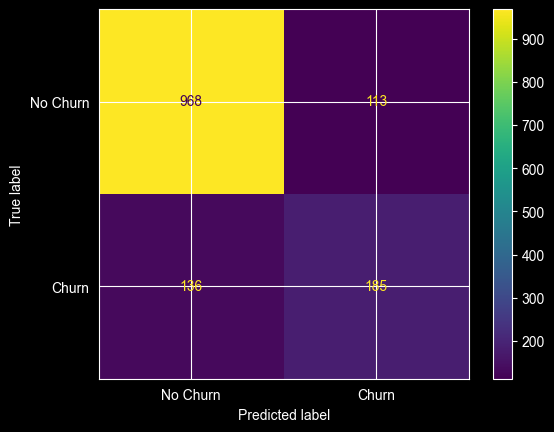

In [19]:
# Task 7 — metrics + confusion matrix
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("accuracy : ",accuracy)
print("precision : ",precision)
print("recall : ",recall)
print("f1 score : ",f1)
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Churn","Churn"])
disp.plot()
plt.show()


**Task 7 — Logistic Regression Metrics**

| Metric | Value |
|---|-------|
| Accuracy | 82.2% |
| Precision | 62.0% |
| Recall | 57.6% |
| F1-score | 59.7% |

In [20]:
# Task 8 — inspect predict_proba for a few test customers
y_pred_proba=model.predict_proba(x_test_scaled)
print(y_pred_proba[:5])


[[0.90450174 0.09549826]
 [0.91252243 0.08747757]
 [0.45745185 0.54254815]
 [0.58490198 0.41509802]
 [0.98435229 0.01564771]]


**Answer 8:**
The probabilities show how likely each customer is to belong to No Churn or Churn. The `predict()` function uses these probabilities to make the final class decision: 0 for No Churn and 1 for Churn.


---

## 4. KNN & Choosing K

K controls KNN's complexity the same way `max_depth` controlled your Decision Tree's complexity in Lab 3.

*Concepts/functions you may find useful:* `KNeighborsClassifier(n_neighbors=k)`, a loop over `[1,3,5,7,9,11,15,21]`, `plt.plot(...)`

**Tasks**
9. Train KNN classifiers for several values of K on the scaled data. Record test-set accuracy and F1-score for each K in a results table.
10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?
11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [21]:
# Task 9 — loop over K values, record accuracy and F1
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
results=[]
# YOUR CODE HERE
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled,y_train)
    y_pred=model.predict(x_test_scaled)

    accuracy=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append([k,accuracy,f1])
results_df=pd.DataFrame(
    results,
    columns=["K", "Accuracy", "F1"]
)
print(results_df)




    K  Accuracy        F1
0   1  0.723966  0.467675
1   3  0.764622  0.511834
2   5  0.756776  0.488756
3   7  0.771041  0.518741
4   9  0.776034  0.522796
5  11  0.781740  0.537764
6  15  0.786733  0.547655
7  21  0.787447  0.549849


**Task 9 — K Selection Results**

| K | Accuracy | F1-score |
|---|----------|----------|
| 1 | 0.72     | 0.46     |
| 3 | 0.76     | 0.51     |
| 5 | 0.75     | 0.48     |
| 7 | 0.77     | 0.51     |
| 9 | 0.77     | 0.52     |
| 11 | 0.78     | 0.53     |
| 15 | 0.78     | 0.54     |
| 21 | 0.78     | 0.54     |

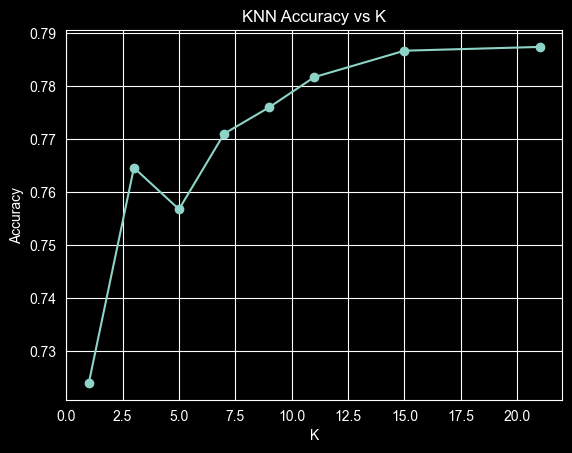

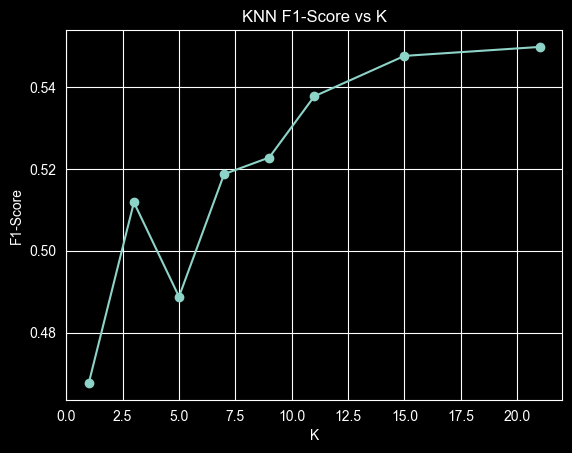

In [22]:
# Task 10 — plot accuracy/F1 vs K
plt.plot(results_df["K"], results_df["Accuracy"], marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

plt.plot(results_df["K"], results_df["F1"], marker="o")
plt.xlabel("K")
plt.ylabel("F1-Score")
plt.title("KNN F1-Score vs K")
plt.show()

**Answer 10 (chosen K and why):**
I would choose K = 21 because it gives the highest F1-score and the highest accuracy among the tested K values. I would not choose K simply because it is the smallest or largest value; the choice should be based on the observed performance of the model.

accuracy :  0.7874465049928673
precision :  0.533724340175953
recall :  0.5669781931464174
f1 score :  0.5498489425981873


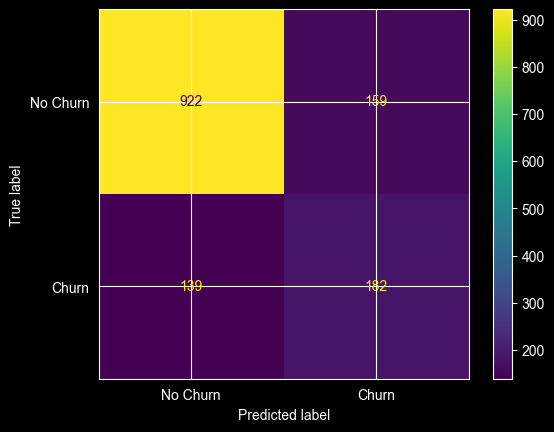

In [23]:
# Task 11 — final KNN model at chosen K: metrics + confusion matrix
final_model=KNeighborsClassifier(n_neighbors=21)
final_model.fit(x_train_scaled,y_train)
y_pred=final_model.predict(x_test_scaled)
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("accuracy : ",accuracy)
print("precision : ",precision_score(y_test,y_pred))
print("recall : ",recall_score(y_test,y_pred))
print("f1 score : ",f1)
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Churn","Churn"])
disp.plot()
plt.show()

**Task 11 — Final KNN Metrics (K = 21)**

| Metric | Value |
|---|-------|
| Accuracy | 78.7% |
| Precision | 53.3% |
| Recall | 56.6% |
| F1-score | 54.9% |

---

## 5. Model Comparison (4 Models)

Place all four classifiers you've built side by side.

**Task**
12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

In [ ]:
# Task 12 — assemble the 4-model comparison table (retrain DT/RF quickly if needed)


**Task 12 — 4-Model Comparison Table**

| Metric | Decision Tree | Random Forest | Logistic Regression | KNN    |
|---|---------------|---------------|---------------------|--------|
| Accuracy | 79.31%        | 80.09%        | 82.20%              | 78.70% |
| Precision | 63.10%        | 66.19%        | 62.00%              | 53.30% |
| Recall | 52.56%        | 50.67%        | 57.6%               | 56.60% |
| F1-score | 57.35%        | 57.40%        | 59.7%               | 54.90% |

**Answer 13:**
Logistic Regression has the highest accuracy, recall, and F1-score among the four models in our results. However, Random Forest has the highest precision, while KNN has a slightly higher recall than the tree-based models. Therefore, the ranking can change depending on which metric is prioritized. Because the dataset has class imbalance, accuracy alone should not be used; recall and F1-score are important for evaluating churn prediction.

---

## 6. Coefficient Interpretation

Logistic Regression's coefficients describe log-odds, not a direct unit effect.

*Concepts/functions you may find useful:* `model.coef_`, `model.intercept_`, `np.exp(coefficient)` (converts log-odds to an odds ratio)

**Tasks**
14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features.
15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

In [26]:
# Task 14 — extract coefficients, compute odds ratios
# Logistic Regression model for Task 14

logistic_model = LogisticRegression()
logistic_model.fit(x_train_scaled, y_train)
coefficients=logistic_model.coef_[0]
odds_ratios=np.exp(coefficients)
coef_df=pd.DataFrame({
    "Feature : " : x.columns,
    "Coefficient : " : coefficients,
    "Odd ratio : " :  odds_ratios
})
print(coef_df)


                               Feature :   Coefficient :   Odd ratio : 
0                           SeniorCitizen        0.090048      1.094227
1                                  tenure       -1.491519      0.225031
2                          MonthlyCharges        0.068827      1.071251
3                            TotalCharges        0.807220      2.241668
4                             gender_Male       -0.017641      0.982513
5                             Partner_Yes        0.002004      1.002006
6                          Dependents_Yes       -0.107274      0.898279
7                        PhoneService_Yes       -0.101684      0.903315
8          MultipleLines_No phone service        0.101684      1.107034
9                       MultipleLines_Yes        0.124410      1.132480
10            InternetService_Fiber optic        0.290640      1.337284
11                     InternetService_No       -0.043682      0.957259
12     OnlineSecurity_No internet service       -0.043682      0

**Task 14 — Coefficient / Odds Ratio Table**
| Feature | Coefficient | Odds Ratio | Interpretation |
|---|---:|---:|---|
| SeniorCitizen | 0.090 | 1.094 | SeniorCitizen has a positive coefficient and an odds ratio greater than 1, indicating higher odds of churn. |
| tenure | -1.492 | 0.225 | Tenure has a negative coefficient and an odds ratio less than 1, indicating lower odds of churn for customers with higher tenure. |
| TotalCharges | 0.807 | 2.242 | TotalCharges has a positive coefficient and an odds ratio greater than 1, indicating higher odds of churn. |
| Contract_Two year | -0.563 | 0.569 | Contract_Two year has a negative coefficient and an odds ratio less than 1, indicating lower odds of churn compared with the reference contract category. |

**Answer 15:**
Lab 2 EDA and Lab 3 Decision Tree results showed that features such as tenure and contract were important for predicting customer churn. The Logistic Regression results also show that tenure and contract have noticeable coefficients and odds ratios, so these findings generally agree with the earlier analysis. However, some differences can occur because Logistic Regression and Decision Tree measure feature effects in different ways. Therefore, the important features are not expected to be exactly the same across all three methods.

---

## 7. Final Model Selection & Conclusion

Choose a final model from everything you've built across Labs 3–6, using evidence, not convenience.

**Tasks**
16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Section 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Answer 16 (final model and justification):**
I selected Logistic Regression as the final model because it achieved the highest accuracy, recall, and F1-score in the Section 5 comparison table. However, based on the Lab 4 cross-validation lesson, a single test result should not be trusted too much, so further validation would be useful before making a final decision.

**Answer 17 — Conclusion:**
In this lab, Logistic Regression achieved the best overall results among the four tested models, with an accuracy of 82.20% and an F1-score of 59.70%. This is higher than the best results from Labs 3–4, where the tuned Random Forest achieved 80.09% accuracy and 57.40% F1-score. Feature scaling was important for KNN because it uses distances, and it also supported Logistic Regression by putting features on a similar scale. KNN achieved 78.70% accuracy and 54.90% F1-score with K=21, so it performed below Logistic Regression in our results. The remaining limitation is that the dataset has class imbalance, so accuracy alone is not enough to judge the model. The results are also based on a single train-test evaluation, so cross-validation would provide more reliable evidence. In the next step, I would use cross-validation and further evaluate the model using metrics such as recall and F1-score.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition & Dataset Verification (with Lab 3/4 recap)
- [ ] Section 2 — Feature Scaling & Preparation (scaler fit on training data only, explained)
- [ ] Section 3 — Logistic Regression (all four metrics + confusion matrix + predict_proba discussion)
- [ ] Section 4 — KNN & Choosing K (results table, plot, justified K choice, final metrics)
- [ ] Section 5 — Model Comparison (all four models, all four metrics)
- [ ] Section 6 — Coefficient Interpretation (odds ratios + connection to earlier labs)
- [ ] Section 7 — Final Model Selection & Conclusion
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted